In [1]:
import sys
sys.path.append('../') # Agar Jupyter bisa melihat folder src
from src.olah_data import load_data_kesehatan

df = load_data_kesehatan()
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [3]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


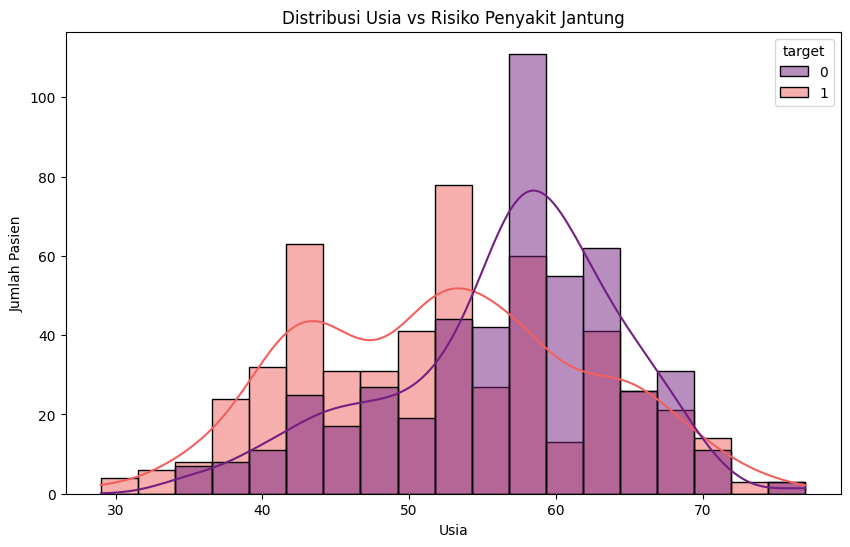

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='target', kde=True, palette='magma')
plt.title('Distribusi Usia vs Risiko Penyakit Jantung')
plt.xlabel('Usia')
plt.ylabel('Jumlah Pasien')
plt.show()

In [5]:
from sqlalchemy import create_engine

# 1. Masukkan informasi yang benar di sini
user = 'postgres' # User default PostgreSQL
password = 'Oke123*' # Ganti dengan password pgAdmin kamu
host = 'localhost'
port = '5432'
db_name = 'db_health' # Sesuaikan dengan nama yang kamu buat di pgAdmin

# 2. Gabungkan menjadi alamat (URL)
url_db = f'postgresql://{user}:{password}@{host}:{port}/{db_name}'

# 3. Buat engine dan kirim data
try:
    engine = create_engine(url_db)
    df.to_sql('pasien_jantung', engine, if_exists='replace', index=False)
    print("Mantap! Data berhasil dikirim ke PostgreSQL!")
except Exception as e:
    print(f"Waduh, masih error nih. Pesannya: {e}")

OperationalError: (psycopg2.OperationalError) connection to server at "localhost" (::1), port 5432 failed: FATAL:  password authentication failed for user "username"

(Background on this error at: https://sqlalche.me/e/20/e3q8)